In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import os

In [3]:
train_df = pd.read_csv(r'C:\Users\Ismail\Documents\medical-segmentation\data\splits\train.csv')
val_df   = pd.read_csv(r'C:\Users\Ismail\Documents\medical-segmentation\data\splits\val.csv')
test_df  = pd.read_csv(r'C:\Users\Ismail\Documents\medical-segmentation\data\splits\test.csv')

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 2144 | Val: 460 | Test: 460


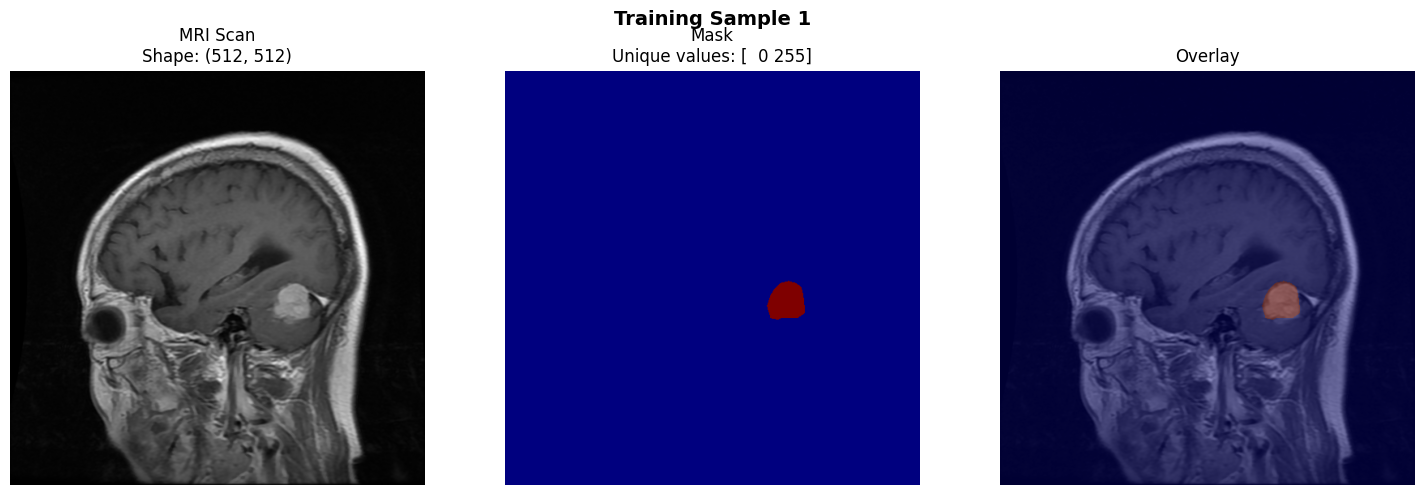

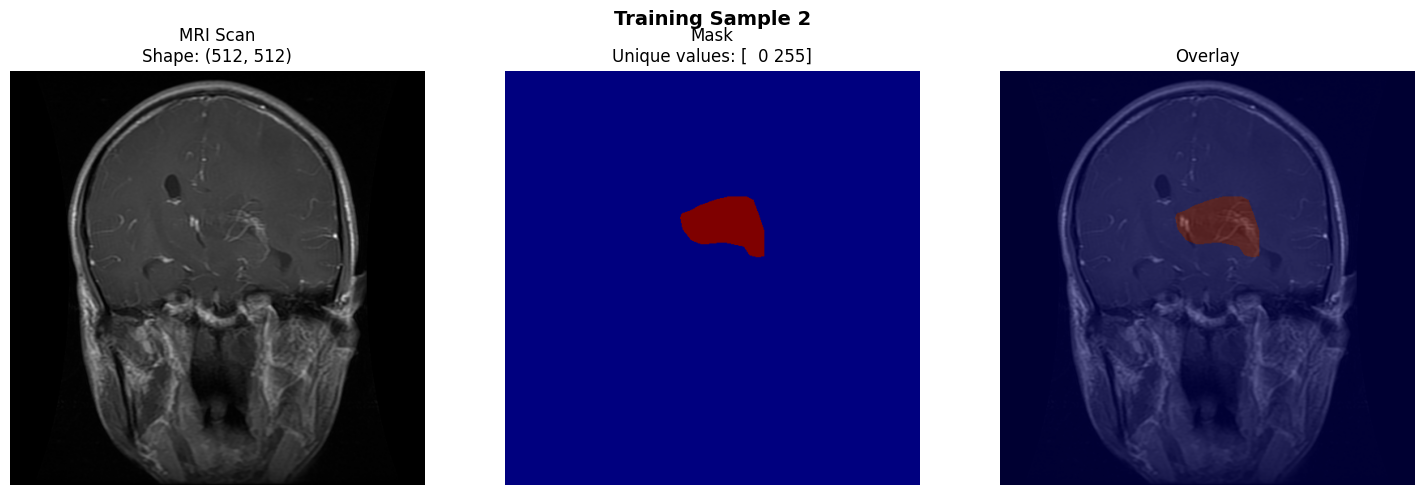

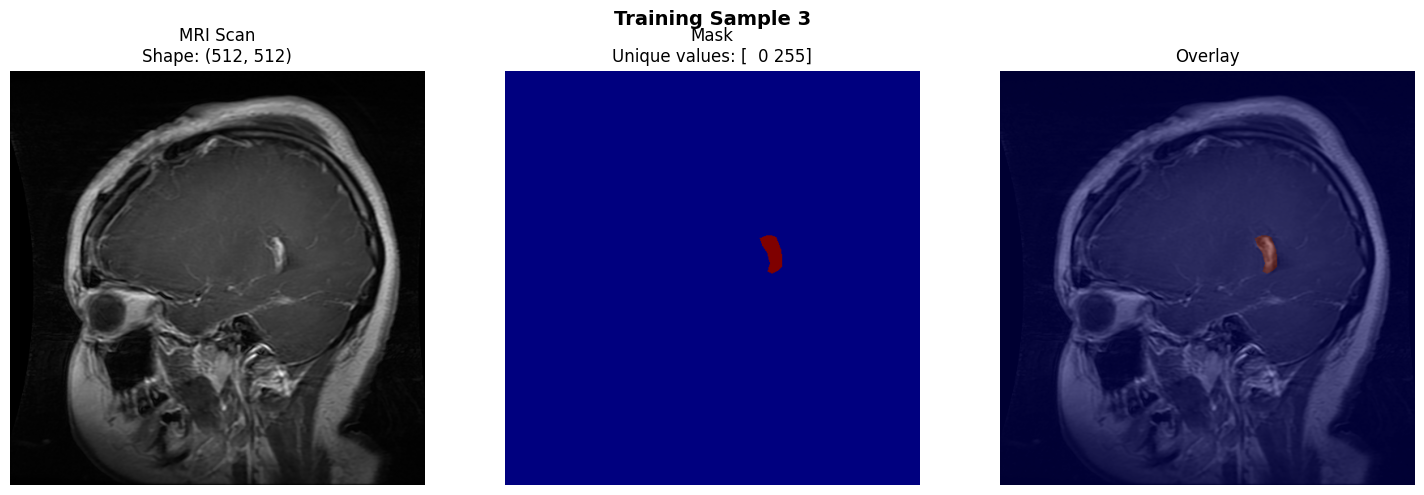

In [4]:
def visualize_sample(img_path, mask_path, title="Sample"):
    img  = np.array(Image.open(img_path).convert('L'))
    mask = np.array(Image.open(mask_path).convert('L'))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'MRI Scan\nShape: {img.shape}')
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='jet')
    axes[1].set_title(f'Mask\nUnique values: {np.unique(mask)}')
    axes[1].axis('off')

    axes[2].imshow(img, cmap='gray')
    axes[2].imshow(mask, cmap='jet', alpha=0.4)
    axes[2].set_title('Overlay')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # Show 3 samples
for i in range(3):
    visualize_sample(
        train_df['image'].iloc[i],
        train_df['mask'].iloc[i],
        title=f"Training Sample {i+1}"
    )

In [5]:
# Check what pixel values exist in masks
print("Checking mask pixel values...")
sample_masks = train_df['mask'].iloc[:50].tolist()

all_unique = set()
for mask_path in sample_masks:
    mask = np.array(Image.open(mask_path).convert('L'))
    all_unique.update(np.unique(mask).tolist())

print(f"Unique pixel values found in masks: {sorted(all_unique)}")
print("\n💡 Use this to set the correct threshold in dataset.py")
print("   If values are [0, 255]  → threshold at 127")
print("   If values are [0, 128, 255] → 0=bg, 128=border, 255=tumor")

Checking mask pixel values...
Unique pixel values found in masks: [0, 255]

💡 Use this to set the correct threshold in dataset.py
   If values are [0, 255]  → threshold at 127
   If values are [0, 128, 255] → 0=bg, 128=border, 255=tumor


Tumor present : 2144
Background only: 0


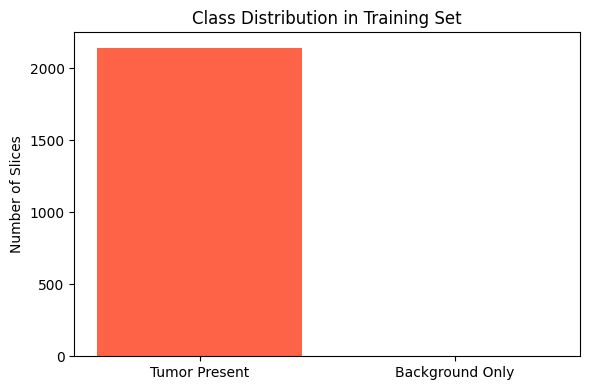

In [7]:
tumor_present = 0
bg_only = 0

for mask_path in train_df['mask'].tolist():
    mask = np.array(Image.open(mask_path).convert('L'))
    if mask.max() > 10:
        tumor_present += 1
    else:
        bg_only += 1

print(f"Tumor present : {tumor_present}")
print(f"Background only: {bg_only}")

plt.figure(figsize=(6, 4))
plt.bar(['Tumor Present', 'Background Only'],
        [tumor_present, bg_only],
        color=['tomato', 'steelblue'])
plt.title('Class Distribution in Training Set')
plt.ylabel('Number of Slices')
plt.tight_layout()
plt.savefig(r'C:\Users\Ismail\Documents\medical-segmentation\outputs\class_distribution.png')
plt.show()